# Tenis — Analiza udarcev (Forehand vs Backhand)
Korak za korakom: vizualizacija, statistike, prag, confusion matrix.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ── NALOŽI FAJLE ──────────────────────────────────────────────────────────────
FH_FILE = './Zajemi/FH_trial_2.json'
BH_FILE = './Zajemi/BH_trial_2.json'

with open(FH_FILE) as f:
    fh_raw = json.load(f)
with open(BH_FILE) as f:
    bh_raw = json.load(f)

def extract(data):
    s = data['samples']
    t = np.array([x['t'] for x in s])
    t = (t - t[0]) / 1000
    return {ch: np.array([x[ch] for x in s]) for ch in ['ax','ay','az','gx','gy','gz','t']}

fh = extract(fh_raw)
bh = extract(bh_raw)
print(f"FH: {len(fh['t'])} vzorcev, {fh['t'][-1]:.1f}s")
print(f"BH: {len(bh['t'])} vzorcev, {bh['t'][-1]:.1f}s")

FH: 7880 vzorcev, 1779798121149.0s
BH: 8838 vzorcev, 1779798353010.0s


## 1 — Statistične metrike (vsi kanali)

In [2]:
channels = ['ax','ay','az','gx','gy','gz']
units    = ['m/s²','m/s²','m/s²','°/s','°/s','°/s']
print(f"{'Kanal':<6} {'Enota':<6} {'FH min':>10} {'FH max':>10} {'FH μ':>10} {'FH σ':>10}  |  {'BH min':>10} {'BH max':>10} {'BH μ':>10} {'BH σ':>10}")
print('-'*105)
for ch, unit in zip(channels, units):
    fv, bv = fh[ch], bh[ch]
    print(f"{ch:<6} {unit:<6} {fv.min():>10.2f} {fv.max():>10.2f} {fv.mean():>10.2f} {fv.std():>10.2f}  |  {bv.min():>10.2f} {bv.max():>10.2f} {bv.mean():>10.2f} {bv.std():>10.2f}")

Kanal  Enota      FH min     FH max       FH μ       FH σ  |      BH min     BH max       BH μ       BH σ
---------------------------------------------------------------------------------------------------------
ax     m/s²       -83.21      13.66      -6.49      13.84  |      -65.22       8.02      -3.96      10.42
ay     m/s²       -12.80      55.28       5.80      12.74  |       -7.91      50.76       4.68       9.38
az     m/s²       -43.75      36.82       1.78       7.32  |      -29.07      20.97      -0.35       4.87
gx     °/s       -362.14     889.63      63.35     182.38  |     -759.28     322.71      -5.71     145.20
gy     °/s       -350.25     428.13     -21.46     111.71  |     -386.60     357.59       6.57      68.92
gz     °/s       -695.01     522.36      47.15     144.31  |     -837.35     415.23       2.75     165.12


## 2 — Cel signal (žiroskop)

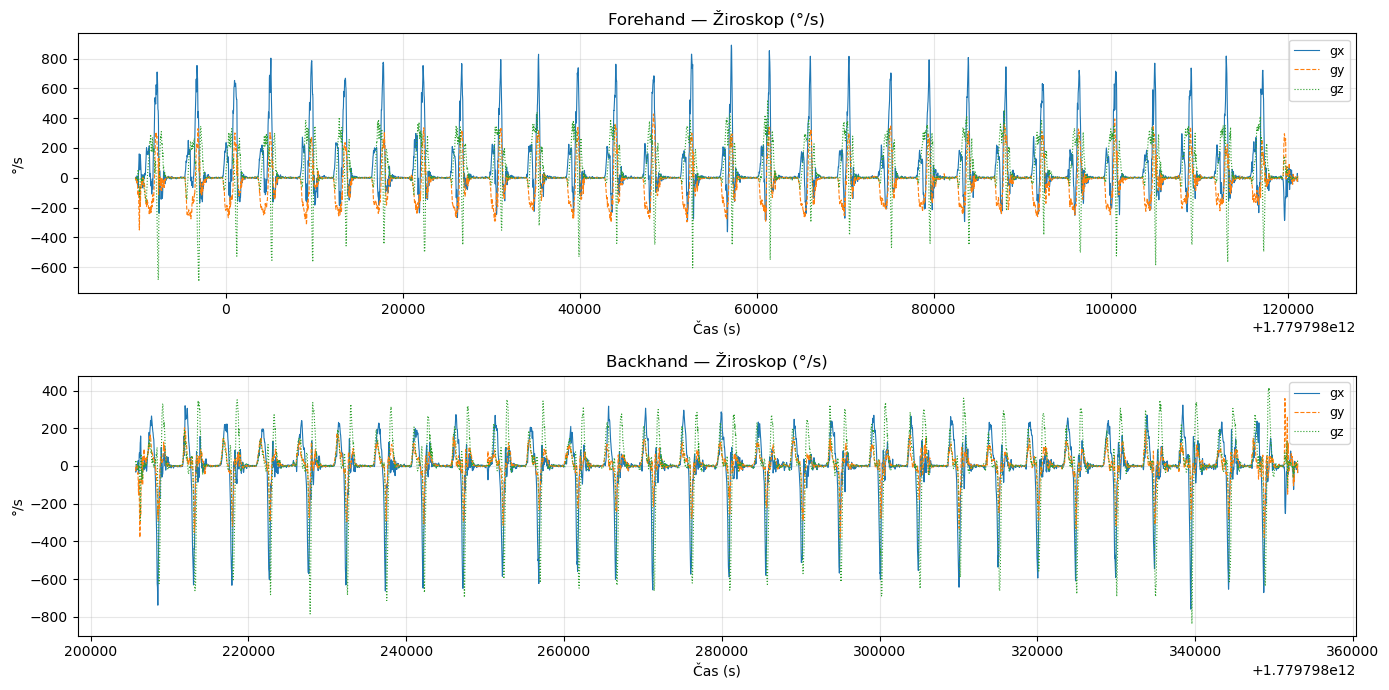

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax_plot, data, color, label in zip(axes, [fh, bh], ['#e8c84a','#4ab8e8'], ['Forehand','Backhand']):
    for ch, ls in zip(['gx','gy','gz'], ['-','--',':']):
        ax_plot.plot(data['t'], data[ch], linewidth=0.8, linestyle=ls, label=ch)
    ax_plot.set_title(f'{label} — Žiroskop (°/s)', fontsize=12)
    ax_plot.set_xlabel('Čas (s)'); ax_plot.set_ylabel('°/s')
    ax_plot.legend(fontsize=9); ax_plot.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./Rezultati/signal_gyr.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 — Cel signal (pospeškometer)

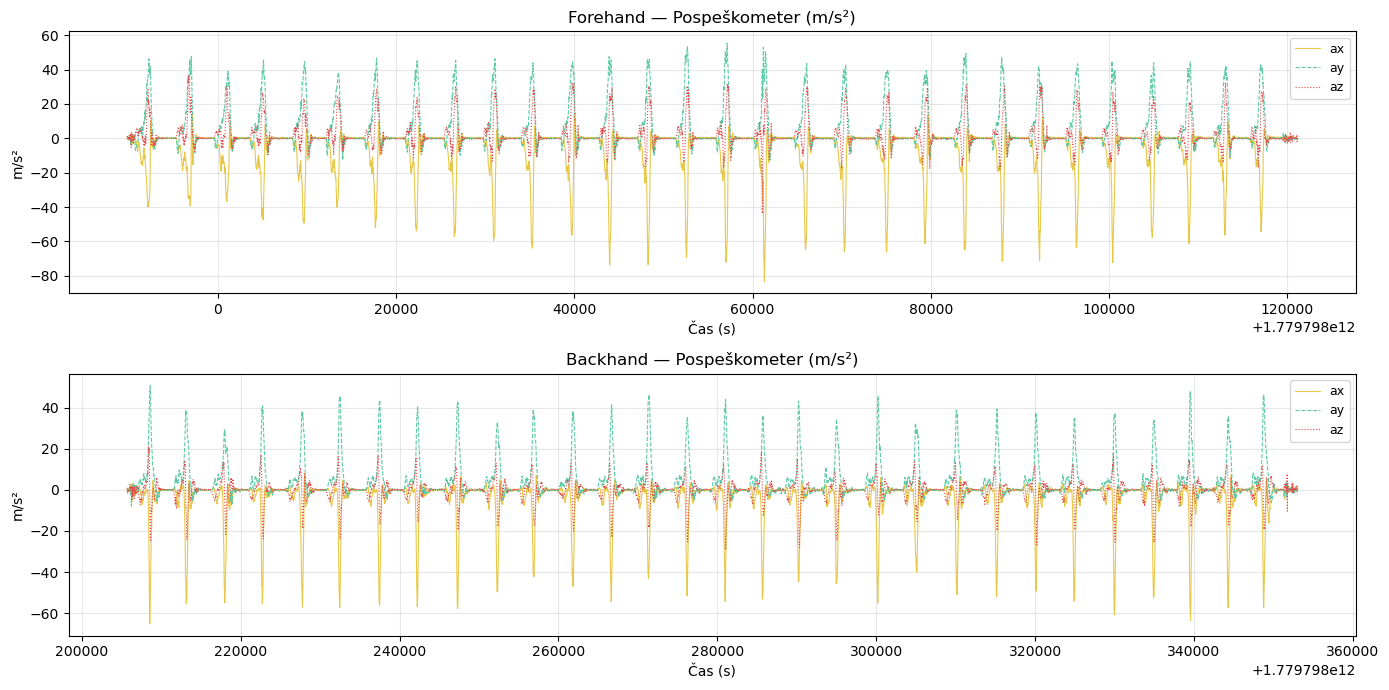

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax_plot, data, label in zip(axes, [fh, bh], ['Forehand','Backhand']):
    for ch, color, ls in zip(['ax','ay','az'], ['#e8c84a','#5dcaa5','#e24b4a'], ['-','--',':']):
        ax_plot.plot(data['t'], data[ch], linewidth=0.8, linestyle=ls, label=ch, color=color)
    ax_plot.set_title(f'{label} — Pospeškometer (m/s²)', fontsize=12)
    ax_plot.set_xlabel('Čas (s)'); ax_plot.set_ylabel('m/s²')
    ax_plot.legend(fontsize=9); ax_plot.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./Rezultati/signal_acc.png', dpi=150, bbox_inches='tight')
plt.show()

4 — Detekcija udarcev (gz os)

threshold = std(signal) * 2.0
Prag = 2× standardni odklon celega signala. Med pavzami je signal blizu 0, med udarcem pa skoči visoko — zato je 2×std dobra meja med "mirovanje" in "udarec".

above = |signal| > threshold
Vsak vzorec dobi True/False — ali je absolutna vrednost nad pragom ali ne.

Korak 3 — Poišči regije
Algoritem gre vzorec po vzorec:

Ko above postane True → začetek udarca
Ko above postane False in ostane False za naslednjih 30 vzorcev → konec udarca
Minimalna razdalja med udarci = 80 vzorcev (~0.8s) da ne zazna istega udarca dvakrat
Rezultat je seznam parov (začetek, konec) za vsakih 30 udarcev.

In [5]:
def detect_strokes(signal, std_multiplier=2.0, min_distance=80):
    """Najde udarce kot regije kjer |gz| > 2*std."""
    threshold = np.std(signal) * std_multiplier
    above = np.abs(signal) > threshold
    strokes, in_stroke, start, last_end = [], False, 0, -min_distance
    for i in range(len(signal)):
        if above[i] and not in_stroke:
            if i - last_end >= min_distance:
                in_stroke, start = True, i
        if in_stroke:
            window = min(i+30, len(signal))
            if not np.any(above[i:window]):
                if i - start > 8:
                    strokes.append((start, i))
                    last_end = i
                in_stroke = False
    return strokes, threshold

fh_strokes, fh_thr = detect_strokes(fh['gz'])
bh_strokes, bh_thr = detect_strokes(bh['gz'])
print(f"FH: zaznanih {len(fh_strokes)} udarcev (prag gz: ±{fh_thr:.1f} °/s)")
print(f"BH: zaznanih {len(bh_strokes)} udarcev (prag gz: ±{bh_thr:.1f} °/s)")

FH: zaznanih 30 udarcev (prag gz: ±288.6 °/s)
BH: zaznanih 30 udarcev (prag gz: ±330.2 °/s)


## 5 — Signal z označenimi udarci

Vizualizacija prejsnega koraka

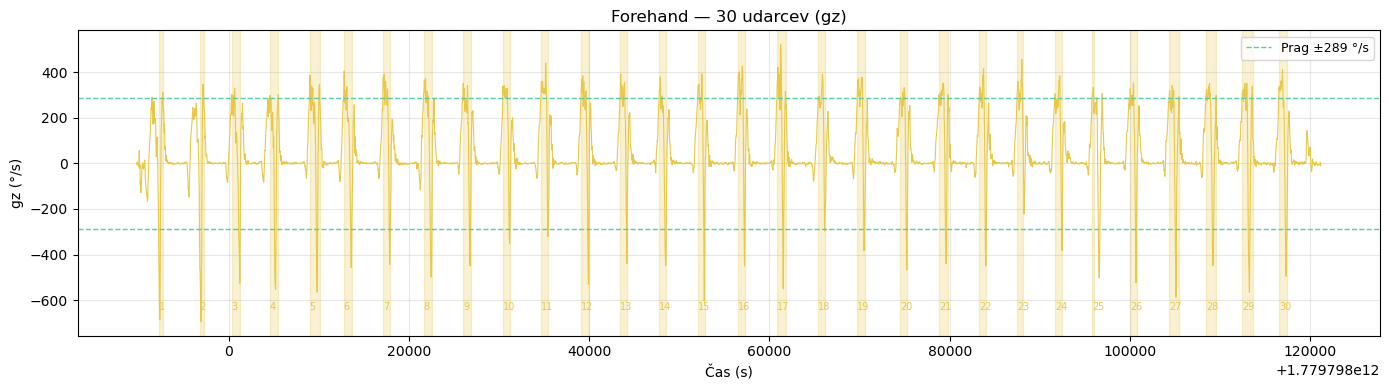

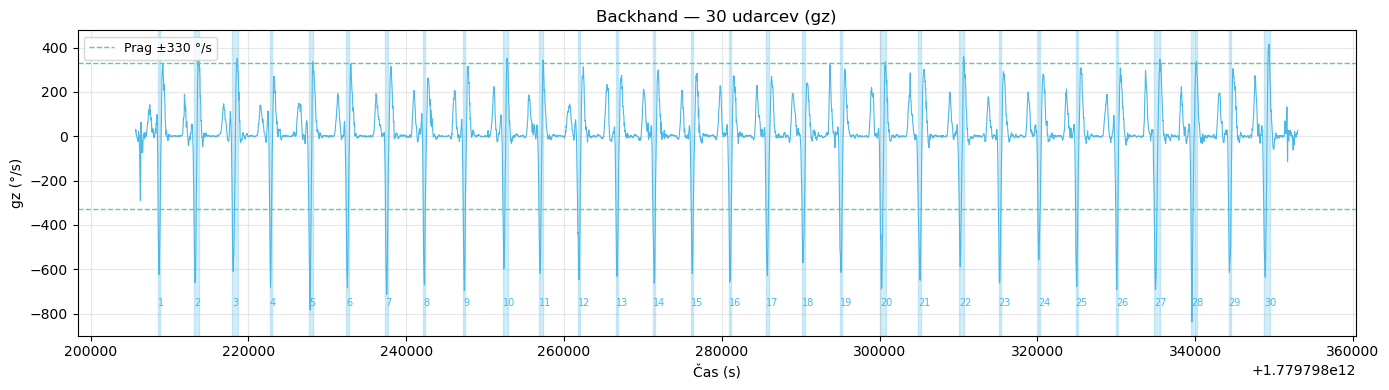

In [6]:
def plot_strokes(data, strokes, threshold, title, color):
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(data['t'], data['gz'], color=color, linewidth=0.8)
    ax.axhline( threshold, color='#5dcaa5', linewidth=1, linestyle='--', label=f'Prag ±{threshold:.0f} °/s')
    ax.axhline(-threshold, color='#5dcaa5', linewidth=1, linestyle='--')
    for i, (s, e) in enumerate(strokes):
        ax.axvspan(data['t'][s], data['t'][e], alpha=0.25, color=color)
        ax.text(data['t'][s], ax.get_ylim()[0]*0.85, str(i+1), fontsize=7, color=color)
    ax.set_title(f'{title} — {len(strokes)} udarcev (gz)', fontsize=12)
    ax.set_xlabel('Čas (s)'); ax.set_ylabel('gz (°/s)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

fig1 = plot_strokes(fh, fh_strokes, fh_thr, 'Forehand', '#e8c84a')
fig1.savefig('./Rezultati/fh_strokes.png', dpi=150, bbox_inches='tight'); plt.show()
fig2 = plot_strokes(bh, bh_strokes, bh_thr, 'Backhand', '#4ab8e8')
fig2.savefig('./Rezultati/bh_strokes.png', dpi=150, bbox_inches='tight'); plt.show()

## 6 — Klasifikacija z gx kanalom
> **gx** je najboljši kanal: FH rotira zapestje v pozitivni smeri (+719 °/s povp.), BH v negativni (-577 °/s povp.)

V koraku 4 smo samo zaznali kje so udarci. Zdaj pa za vsak udarec ugotovimo kateri tip je.
Za vsak zaznani udarec vzamemo okno signala gx (ne gz!) in poiščemo vrh — vrednost z največjo absolutno vrednostjo:
peak = signal[start:end][argmax(|signal[start:end]|)]

Dobimo 30 vrhov za FH in 30 za BH. Potem izračunamo klasifikacijski prag:
threshold = (povprečje FH vrhov + povprečje BH vrhov) / 2
           = (719 + (-577)) / 2
           = 71 °/s

In [7]:
def get_peaks(signal, strokes):
    return np.array([signal[s:e][np.argmax(np.abs(signal[s:e]))] for s,e in strokes])

fh_peaks = get_peaks(fh['gx'], fh_strokes)
bh_peaks = get_peaks(bh['gx'], bh_strokes)

# Klasifikacijski prag = sredina med povprečjema
CLASS_THRESHOLD = (fh_peaks.mean() + bh_peaks.mean()) / 2

print(f"=== STATISTIKE gx po udarcu ===")
print(f"FH: μ={fh_peaks.mean():.1f} °/s, σ={fh_peaks.std():.1f}, min={fh_peaks.min():.1f}, max={fh_peaks.max():.1f}")
print(f"BH: μ={bh_peaks.mean():.1f} °/s, σ={bh_peaks.std():.1f}, min={bh_peaks.min():.1f}, max={bh_peaks.max():.1f}")
print(f"\nKlasifikacijski prag: {CLASS_THRESHOLD:.1f} °/s")
print(f"Pravilo: gx > {CLASS_THRESHOLD:.1f} → FOREHAND | gx < {CLASS_THRESHOLD:.1f} → BACKHAND")

=== STATISTIKE gx po udarcu ===
FH: μ=719.0 °/s, σ=194.8, min=-251.5, max=889.6
BH: μ=-577.1 °/s, σ=59.8, min=-759.3, max=-483.5

Klasifikacijski prag: 71.0 °/s
Pravilo: gx > 71.0 → FOREHAND | gx < 71.0 → BACKHAND


## 7 — Porazdelitev vrhov gx
Vizualizacija prejsnega koraka
Vzameš 30 FH vrhov in 30 BH vrhov iz koraka 6 in narišeš histogram — koliko udarcev pade v vsak "koš" vrednosti.

Poleg histograma so narisane še tri navpične črte:

Rumena črtkana — povprečje FH (+719)
Modra črtkana — povprečje BH (-577)
Bela polna — klasifikacijski prag (71)

Namen
Pokažeš da sta FH in BH dobro ločeni skupini — malo ali nič prekrivanja med histogramoma. Bolj sta skupini ločeni, višja je točnost klasifikacije.

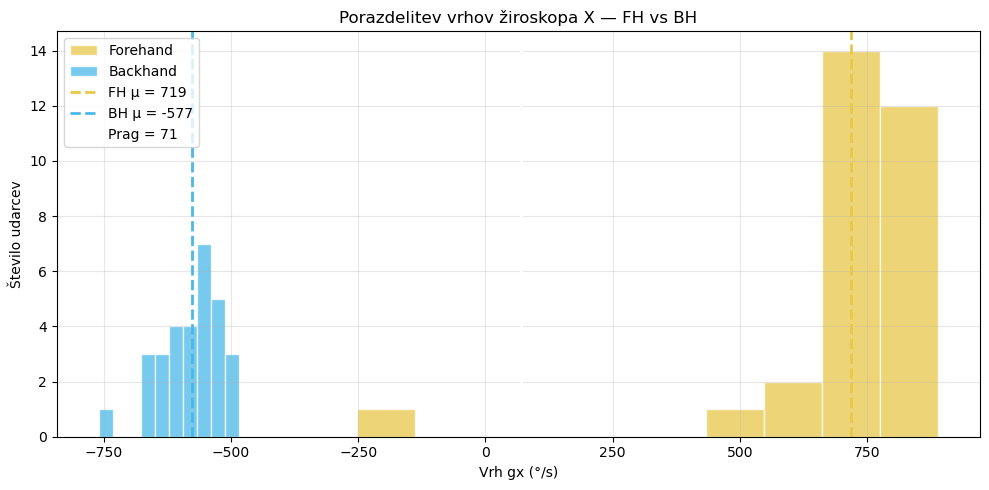

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(fh_peaks, bins=10, color='#e8c84a', alpha=0.75, label='Forehand', edgecolor='white')
ax.hist(bh_peaks, bins=10, color='#4ab8e8', alpha=0.75, label='Backhand', edgecolor='white')
ax.axvline(fh_peaks.mean(), color='#e8c84a', linestyle='--', linewidth=2, label=f'FH μ = {fh_peaks.mean():.0f}')
ax.axvline(bh_peaks.mean(), color='#4ab8e8', linestyle='--', linewidth=2, label=f'BH μ = {bh_peaks.mean():.0f}')
ax.axvline(CLASS_THRESHOLD,  color='white',   linestyle='-',  linewidth=2, label=f'Prag = {CLASS_THRESHOLD:.0f}')
ax.set_xlabel('Vrh gx (°/s)'); ax.set_ylabel('Število udarcev')
ax.set_title('Porazdelitev vrhov žiroskopa X — FH vs BH')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./Rezultati/porazdelitev.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 — Confusion matrix + Potrditev H1
tp = koliko FH vrhov je algoritem napovedal kot FH  →  29
fn = koliko FH vrhov je algoritem napovedal kot BH  →   1
fp = koliko BH vrhov je algoritem napovedal kot FH  →   0
tn = koliko BH vrhov je algoritem napovedal kot BH  →  30

Čeprav smo posneli vseh 6 kanalov (ax, ay, az, gx, gy, gz), smo za analizo uporabili samo žiroskop:

gz — za detekcijo udarcev (korak 4) — ker gz dobro pokaže kdaj se udarec zgodi
gx — za klasifikacijo FH/BH (korak 6) — ker gx loči smer rotacije zapestja

Z žiroskopom (os X) pri 100 Hz vzorčenja lahko ločimo forehand od backhanda z natančnostjo ≥ 85 %.

                          Napoved: FH    Napoved: BH
          Dejansko: FH             29              1
          Dejansko: BH              0             30

Točnost    (Accuracy):  98.3%
Natančnost (Precision): 100.0%
Priklic    (Recall):    96.7%
F1 Score:               98.3%


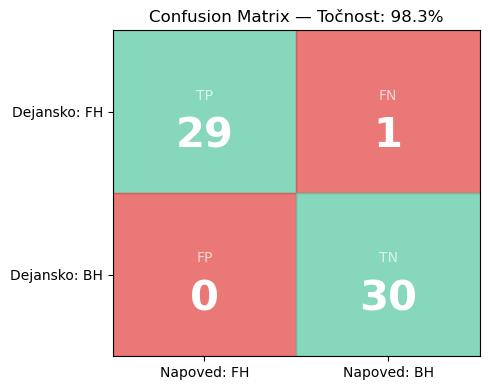


H1: ✅ POTRJENA
Točnost 98.3% ≥ 85% (prag za potrditev)
Uporabljen kanal: gx (rotacija zapestja X os)
Prag: 71.0 °/s


In [9]:
tp = int(np.sum(fh_peaks >= CLASS_THRESHOLD))
fn = int(np.sum(fh_peaks <  CLASS_THRESHOLD))
fp = int(np.sum(bh_peaks >= CLASS_THRESHOLD))
tn = int(np.sum(bh_peaks <  CLASS_THRESHOLD))

accuracy  = (tp + tn) / 60 * 100
precision = tp / (tp + fp) * 100 if (tp+fp) > 0 else 0
recall    = tp / (tp + fn) * 100 if (tp+fn) > 0 else 0
f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

print(f"{'':>22} {'Napoved: FH':>14} {'Napoved: BH':>14}")
print(f"{'Dejansko: FH':>22} {tp:>14} {fn:>14}")
print(f"{'Dejansko: BH':>22} {fp:>14} {tn:>14}")
print(f"\nTočnost    (Accuracy):  {accuracy:.1f}%")
print(f"Natančnost (Precision): {precision:.1f}%")
print(f"Priklic    (Recall):    {recall:.1f}%")
print(f"F1 Score:               {f1:.1f}%")

# Vizualizacija
fig, ax = plt.subplots(figsize=(5, 4))
matrix = [[tp, fn],[fp, tn]]
clrs   = [['#5dcaa5','#e24b4a'],['#e24b4a','#5dcaa5']]
lbls   = [['TP','FN'],['FP','TN']]
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j,1-i),1,1,color=clrs[i][j],alpha=0.75))
        ax.text(j+0.5,1-i+0.6,lbls[i][j],ha='center',va='center',fontsize=10,color='white',alpha=0.7)
        ax.text(j+0.5,1-i+0.35,str(matrix[i][j]),ha='center',va='center',fontsize=30,fontweight='bold',color='white')
ax.set_xlim(0,2); ax.set_ylim(0,2)
ax.set_xticks([0.5,1.5]); ax.set_xticklabels(['Napoved: FH','Napoved: BH'])
ax.set_yticks([0.5,1.5]); ax.set_yticklabels(['Dejansko: BH','Dejansko: FH'])
ax.set_title(f'Confusion Matrix — Točnost: {accuracy:.1f}%', fontsize=12)
plt.tight_layout()
plt.savefig('./Rezultati/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*40}")
print(f"H1: {'✅ POTRJENA' if accuracy >= 85 else '❌ ZAVRNJENA'}")
print(f"Točnost {accuracy:.1f}% {'≥' if accuracy >= 85 else '<'} 85% (prag za potrditev)")
print(f"Uporabljen kanal: gx (rotacija zapestja X os)")
print(f"Prag: {CLASS_THRESHOLD:.1f} °/s")

## H2 — Backhand: leva vs desna roka
> **ax** je najboljši kanal: leva roka μ=+42.9 m/s², desna roka μ=-53.2 m/s² — zamah v nasprotnih smereh

In [10]:
# Naloži levi backhand
BHL_FILE = './Zajemi/BH_left_1.json'
with open(BHL_FILE) as f:
    bhl_raw = json.load(f)

left  = extract(bhl_raw)
right = bh  # že naložen prej

left_strokes,  _ = detect_strokes(left['ax'])
right_strokes, _ = detect_strokes(right['gz'])

print(f"Leva:  {len(left_strokes)} udarcev")
print(f"Desna: {len(right_strokes)} udarcev")

Leva:  30 udarcev
Desna: 30 udarcev


In [11]:
left_peaks  = get_peaks(left['ax'],  left_strokes)
right_peaks = get_peaks(right['ax'], right_strokes)

CLASS_THRESHOLD_H2 = (left_peaks.mean() + right_peaks.mean()) / 2

print(f"=== STATISTIKE ax po udarcu ===")
print(f"Leva:  μ={left_peaks.mean():.1f} m/s², σ={left_peaks.std():.1f}, min={left_peaks.min():.1f}, max={left_peaks.max():.1f}")
print(f"Desna: μ={right_peaks.mean():.1f} m/s², σ={right_peaks.std():.1f}, min={right_peaks.min():.1f}, max={right_peaks.max():.1f}")
print(f"\nKlasifikacijski prag: {CLASS_THRESHOLD_H2:.1f} m/s²")
print(f"Pravilo: ax > {CLASS_THRESHOLD_H2:.1f} → LEVA | ax < {CLASS_THRESHOLD_H2:.1f} → DESNA")

=== STATISTIKE ax po udarcu ===
Leva:  μ=42.9 m/s², σ=4.6, min=34.2, max=51.3
Desna: μ=-53.2 m/s², σ=5.9, min=-65.2, max=-40.1

Klasifikacijski prag: -5.1 m/s²
Pravilo: ax > -5.1 → LEVA | ax < -5.1 → DESNA


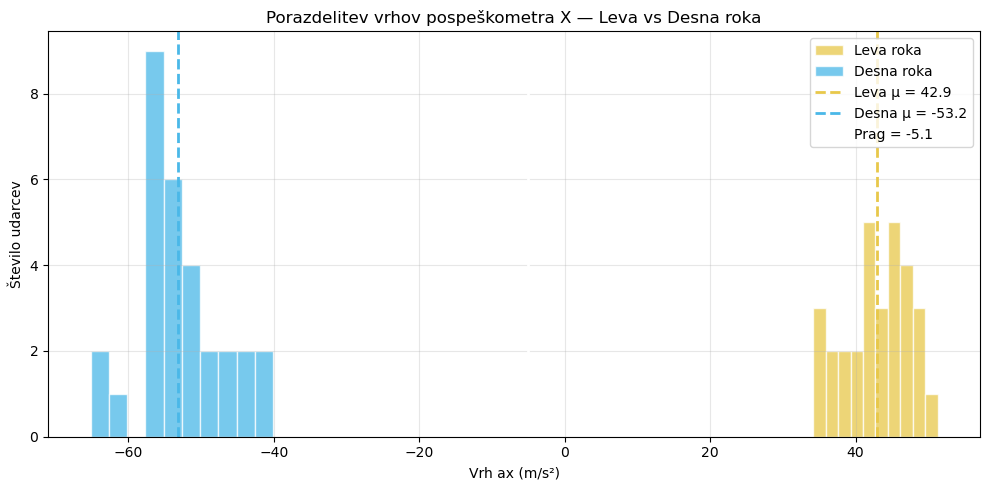

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(left_peaks,  bins=10, color='#e8c84a', alpha=0.75, label='Leva roka',  edgecolor='white')
ax.hist(right_peaks, bins=10, color='#4ab8e8', alpha=0.75, label='Desna roka', edgecolor='white')
ax.axvline(left_peaks.mean(),      color='#e8c84a', linestyle='--', linewidth=2, label=f'Leva μ = {left_peaks.mean():.1f}')
ax.axvline(right_peaks.mean(),     color='#4ab8e8', linestyle='--', linewidth=2, label=f'Desna μ = {right_peaks.mean():.1f}')
ax.axvline(CLASS_THRESHOLD_H2,     color='white',   linestyle='-',  linewidth=2, label=f'Prag = {CLASS_THRESHOLD_H2:.1f}')
ax.set_xlabel('Vrh ax (m/s²)'); ax.set_ylabel('Število udarcev')
ax.set_title('Porazdelitev vrhov pospeškometra X — Leva vs Desna roka')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./Rezultati/porazdelitev_h2.png', dpi=150, bbox_inches='tight')
plt.show()

                        Napoved: Leva  Napoved: Desna
        Dejansko: Leva             30               0
       Dejansko: Desna              0              30

Točnost:    100.0%
Natančnost: 100.0%
Priklic:    100.0%
F1:         100.0%


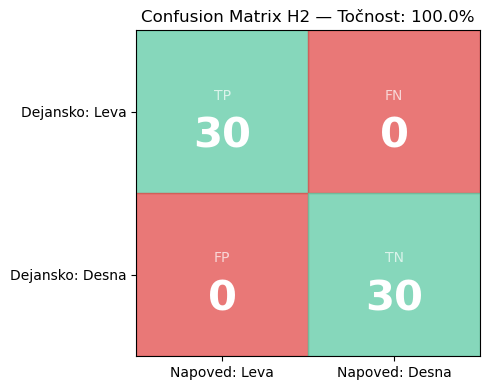


H2: ✅ POTRJENA
Točnost 100.0% ≥ 85% (prag za potrditev)
Uporabljen kanal: ax (lateralno gibanje roke)
Prag: -5.1 m/s²


In [13]:
tp = int(np.sum(left_peaks  >= CLASS_THRESHOLD_H2))
fn = int(np.sum(left_peaks  <  CLASS_THRESHOLD_H2))
fp = int(np.sum(right_peaks >= CLASS_THRESHOLD_H2))
tn = int(np.sum(right_peaks <  CLASS_THRESHOLD_H2))

accuracy  = (tp + tn) / 60 * 100
precision = tp / (tp + fp) * 100 if (tp+fp) > 0 else 0
recall    = tp / (tp + fn) * 100 if (tp+fn) > 0 else 0
f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

print(f"{'':>22} {'Napoved: Leva':>14} {'Napoved: Desna':>15}")
print(f"{'Dejansko: Leva':>22} {tp:>14} {fn:>15}")
print(f"{'Dejansko: Desna':>22} {fp:>14} {tn:>15}")
print(f"\nTočnost:    {accuracy:.1f}%")
print(f"Natančnost: {precision:.1f}%")
print(f"Priklic:    {recall:.1f}%")
print(f"F1:         {f1:.1f}%")

fig, ax = plt.subplots(figsize=(5, 4))
matrix = [[tp, fn],[fp, tn]]
clrs   = [['#5dcaa5','#e24b4a'],['#e24b4a','#5dcaa5']]
lbls   = [['TP','FN'],['FP','TN']]
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j,1-i),1,1,color=clrs[i][j],alpha=0.75))
        ax.text(j+0.5,1-i+0.6,lbls[i][j],ha='center',va='center',fontsize=10,color='white',alpha=0.7)
        ax.text(j+0.5,1-i+0.35,str(matrix[i][j]),ha='center',va='center',fontsize=30,fontweight='bold',color='white')
ax.set_xlim(0,2); ax.set_ylim(0,2)
ax.set_xticks([0.5,1.5]); ax.set_xticklabels(['Napoved: Leva','Napoved: Desna'])
ax.set_yticks([0.5,1.5]); ax.set_yticklabels(['Dejansko: Desna','Dejansko: Leva'])
ax.set_title(f'Confusion Matrix H2 — Točnost: {accuracy:.1f}%', fontsize=12)
plt.tight_layout()
plt.savefig('./Rezultati/confusion_matrix_h2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*40}")
print(f"H2: {'✅ POTRJENA' if accuracy >= 85 else '❌ ZAVRNJENA'}")
print(f"Točnost {accuracy:.1f}% {'≥' if accuracy >= 85 else '<'} 85% (prag za potrditev)")
print(f"Uporabljen kanal: ax (lateralno gibanje roke)")
print(f"Prag: {CLASS_THRESHOLD_H2:.1f} m/s²")

## H3 — Hiter vs počasen forehand
> S pospeškometrom (amplituda |a| = √(ax²+ay²+az²)) pri 100 Hz lahko ločimo hiter forehand od počasnega z natančnostjo ≥ 80%.
magnituda ali amplituda pospeška — ena številka ki pove skupno intenziteto gibanja roke v vseh smereh hkrati.
Torej:

Hiter udarec → roka se giblje hitro → velika magnituda (~137 m/s²)
Počasen udarec → roka se giblje počasi → majhna magnituda (~37 m/s²)


In [14]:
# Naloži počasen in hiter forehand
with open('./Zajemi/FH_slow_1.json') as f:
    slow_raw = json.load(f)
with open('./Zajemi/FH_fast_1.json') as f:
    fast_raw = json.load(f)

slow = extract(slow_raw)
fast = extract(fast_raw)

slow_strokes, slow_thr = detect_strokes(slow['ax'])
fast_strokes, fast_thr = detect_strokes(fast['ax'])

print(f"Slow: {len(slow_strokes)} udarcev | Fast: {len(fast_strokes)} udarcev")

Slow: 30 udarcev | Fast: 29 udarcev


In [15]:
def get_mag_peaks(data, strokes):
    mag = np.sqrt(data['ax']**2 + data['ay']**2 + data['az']**2)
    return np.array([mag[s:e].max() for s,e in strokes])

slow_mag = get_mag_peaks(slow, slow_strokes)
fast_mag = get_mag_peaks(fast, fast_strokes)

print(f"=== STATISTIKE amplitude pospeška ===")
print(f"Slow: μ={slow_mag.mean():.1f}, σ={slow_mag.std():.1f}, min={slow_mag.min():.1f}, max={slow_mag.max():.1f}")
print(f"Fast: μ={fast_mag.mean():.1f}, σ={fast_mag.std():.1f}, min={fast_mag.min():.1f}, max={fast_mag.max():.1f}")

from scipy import stats
t_stat, p_val = stats.ttest_ind(fast_mag, slow_mag)
print(f"\nt-test: t={t_stat:.3f}, p={p_val:.6f}")
print(f"Razlika statistično značilna: {'DA (p < 0.05)' if p_val < 0.05 else 'NE (p >= 0.05)'}")

=== STATISTIKE amplitude pospeška ===
Slow: μ=36.9, σ=17.5, min=21.4, max=90.9
Fast: μ=136.9, σ=16.9, min=91.9, max=164.5

t-test: t=21.940, p=0.000000
Razlika statistično značilna: DA (p < 0.05)


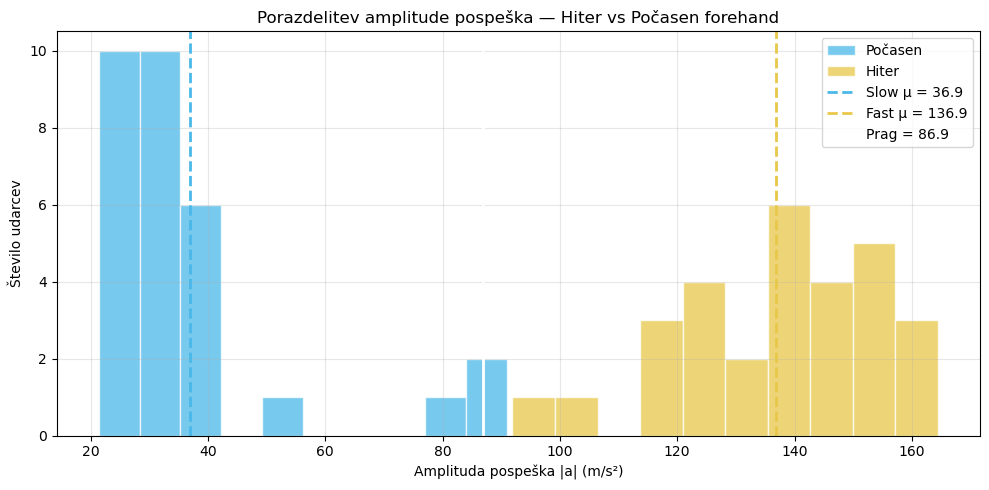

In [16]:
CLASS_THRESHOLD_H3 = (slow_mag.mean() + fast_mag.mean()) / 2

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(slow_mag, bins=10, color='#4ab8e8', alpha=0.75, label='Počasen', edgecolor='white')
ax.hist(fast_mag, bins=10, color='#e8c84a', alpha=0.75, label='Hiter',   edgecolor='white')
ax.axvline(slow_mag.mean(),   color='#4ab8e8', linestyle='--', linewidth=2, label=f'Slow μ = {slow_mag.mean():.1f}')
ax.axvline(fast_mag.mean(),   color='#e8c84a', linestyle='--', linewidth=2, label=f'Fast μ = {fast_mag.mean():.1f}')
ax.axvline(CLASS_THRESHOLD_H3, color='white',  linestyle='-',  linewidth=2, label=f'Prag = {CLASS_THRESHOLD_H3:.1f}')
ax.set_xlabel('Amplituda pospeška |a| (m/s²)'); ax.set_ylabel('Število udarcev')
ax.set_title('Porazdelitev amplitude pospeška — Hiter vs Počasen forehand')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./Rezultati/porazdelitev_h3.png', dpi=150, bbox_inches='tight')
plt.show()

                          Napoved: Fast  Napoved: Slow
          Dejansko: Fast             29              0
          Dejansko: Slow              2             28

Točnost:    96.6%
Natančnost: 93.5%
Priklic:    100.0%
F1:         96.7%
Prag:       -5.1 m/s²


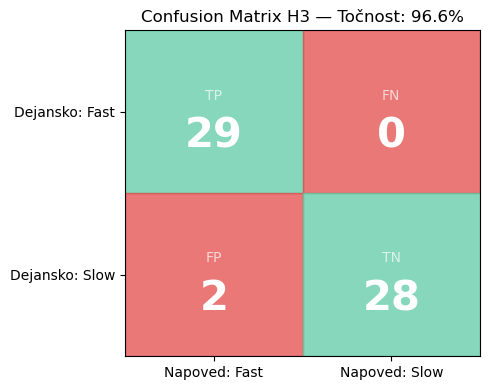


H3: ✅ POTRJENA
Točnost 96.6% ≥ 80% (prag za potrditev)
Uporabljen kanal: amplituda pospeška √(ax²+ay²+az²)
Prag: 86.9 m/s²


In [18]:
tp = int(np.sum(fast_mag >= CLASS_THRESHOLD_H3))
fn = int(np.sum(fast_mag <  CLASS_THRESHOLD_H3))
fp = int(np.sum(slow_mag >= CLASS_THRESHOLD_H3))
tn = int(np.sum(slow_mag <  CLASS_THRESHOLD_H3))

accuracy  = (tp+tn)/(tp+tn+fp+fn)*100
precision = tp/(tp+fp)*100 if (tp+fp)>0 else 0
recall    = tp/(tp+fn)*100 if (tp+fn)>0 else 0
f1        = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0

print(f"{'':>24} {'Napoved: Fast':>14} {'Napoved: Slow':>14}")
print(f"{'Dejansko: Fast':>24} {tp:>14} {fn:>14}")
print(f"{'Dejansko: Slow':>24} {fp:>14} {tn:>14}")
print(f"\nTočnost:    {accuracy:.1f}%")
print(f"Natančnost: {precision:.1f}%")
print(f"Priklic:    {recall:.1f}%")
print(f"F1:         {f1:.1f}%")
print(f"Prag:       {CLASS_THRESHOLD_H2:.1f} m/s²")

fig, ax = plt.subplots(figsize=(5, 4))
matrix = [[tp, fn],[fp, tn]]
clrs   = [['#5dcaa5','#e24b4a'],['#e24b4a','#5dcaa5']]
lbls   = [['TP','FN'],['FP','TN']]
for i in range(2):
    for j in range(2):
        ax.add_patch(plt.Rectangle((j,1-i),1,1,color=clrs[i][j],alpha=0.75))
        ax.text(j+0.5,1-i+0.6,lbls[i][j],ha='center',va='center',fontsize=10,color='white',alpha=0.7)
        ax.text(j+0.5,1-i+0.35,str(matrix[i][j]),ha='center',va='center',fontsize=30,fontweight='bold',color='white')
ax.set_xlim(0,2); ax.set_ylim(0,2)
ax.set_xticks([0.5,1.5]); ax.set_xticklabels(['Napoved: Fast','Napoved: Slow'])
ax.set_yticks([0.5,1.5]); ax.set_yticklabels(['Dejansko: Slow','Dejansko: Fast'])
ax.set_title(f'Confusion Matrix H3 — Točnost: {accuracy:.1f}%', fontsize=12)
plt.tight_layout()
plt.savefig('./Rezultati/confusion_matrix_h3.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*40}")
print(f"H3: {'✅ POTRJENA' if accuracy >= 80 else '❌ ZAVRNJENA'}")
print(f"Točnost {accuracy:.1f}% {'≥' if accuracy >= 80 else '<'} 80% (prag za potrditev)")
print(f"Uporabljen kanal: amplituda pospeška √(ax²+ay²+az²)")
print(f"Prag: {CLASS_THRESHOLD_H3:.1f} m/s²")